## Load packages and define functions

In [1]:
import pandas as pd 
import pyam
import matplotlib.pyplot as plt
import pandas_indexing as pix
from pandas_indexing import isin, ismatch
import numpy as np

import os
from pathlib import Path

from fuzzywuzzy import fuzz

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import data_shepherd as ds
from data_shepherd import utils
import datatoolbox as dt

<IPython.core.display.Javascript object>

In [2]:
def elec(tech=None):
    if not tech is None:
        return f'Secondary Energy|Electricity|{tech}'
    else:
        return 'Secondary Energy|Electricity'

In [3]:
REMIND_RMAP = ds.utils.RegionMapping.from_model('REMIND_2.1')

In [4]:
IKEA_ISOS = ["DEU","POL","BRA","MEX","KEN","MAR","MOZ",
             "NGA","SEN","ZAF","USA","NAM","DZA","TUR","SAU",
             "ARE","BGD","IND","IDN","PAK","VNM","GBR","AUS","CHN","JPN"]

LAM_ISOS = [
    'ABW', 'ARG', 'ATG', 'BHS', 'BLZ', 'BMU', 'BOL', 'BRA', 'BRB', 'CHL', 'COL',
    'CRI', 'CUB', 'CYM', 'DMA', 'DOM', 'ECU', 'FLK', 'GLP', 'GRD', 'GTM', 'GUF',
    'GUY', 'HND', 'HTI', 'JAM', 'KNA', 'LCA', 'MEX', 'MSR', 'MTQ','NIC', 'PAN', 'PER',
    'PRI', 'PRY', 'SLV', 'SUR', 'TCA', 'TTO', 'URY', 'VCT', 'VEN', 'VGB', 'VIR']

IKEA_ISOS.sort()

## Load data

In [5]:
BOX_MOUNT_PATH = Path("~/Library/CloudStorage/Box-Box").expanduser()
if not BOX_MOUNT_PATH.is_dir():
    BOX_MOUNT_PATH = Path("~/Box").expanduser()

In [6]:
DSCALE_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP2 - National 1.5°C Pathways/"
    "Downscaling/"
    "DSCALE"
    
)

DSCALE_PATH: os.PathLike = BOX_MOUNT_PATH / DSCALE_PATH

In [7]:
REMIND_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP1 - Updating global 1.5°C Pathways/"
    "1 - PIK/"
    "Scenario Data/"
    "SUBMITTED_SCENARIOS_August2025/"

)

REMIND_PATH: os.PathLike = BOX_MOUNT_PATH / REMIND_PATH

In [8]:
# INSERT PATHWAY TO INPUT DATA
input_data = pyam.IamDataFrame('../input_data/REMIND_fuel_mix_testing/snapshot_v1/npe_core_scenario_harmonised_AR6_reporting.csv')
# input_data_processed = pyam.IamDataFrame('../input_data/REMIND_fuel_mix_testing/multiple_df/snapshot_all_regions_RAW_REMIND-MAgPIE 3.3-4.8.csv')

pyam - INFO: Running in a notebook, setting up a basic logging at level INFO
pyam.core - INFO: Reading file ../input_data/REMIND_fuel_mix_testing/snapshot_v1/npe_core_scenario_harmonised_AR6_reporting.csv


In [9]:
import pandas as pd

# INSERT PATHWAY TO HISTORICAL DATA HERE
df = pd.read_csv(
    DSCALE_PATH / 'data/step1_input_data_for_DSCALE/input_reference_iea_2022.csv'
)

iamc_cols = ["MODEL", "SCENARIO", "REGION", "VARIABLE", "UNIT"]

df_clean = df.drop_duplicates(
    subset=["MODEL", "SCENARIO", "REGION", "VARIABLE", "UNIT"]
)

hist_data = pyam.IamDataFrame(df_clean)

In [10]:
# PUT PATH TO YOUR DSCALE RESULTS IN HERE
dscale_results = pyam.IamDataFrame('../results/5_Explorer_and_New_Variables/REMIND 3.4_REMIND_fuel_mix_testing_17_02_2026_2022_harmo_step5h_hydrogen.csv')

pyam.core - INFO: Reading file ../results/5_Explorer_and_New_Variables/REMIND 3.4_REMIND_fuel_mix_testing_17_02_2026_2022_harmo_step5h_hydrogen.csv


In [12]:
hist_data_iea = pyam.IamDataFrame(DSCALE_PATH /  'data/step1_input_data_for_DSCALE/input_reference_iea_2022.csv')

pyam.core - INFO: Reading file /Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/IKEA NDC 1.5° Pathways 23-25 - phase II/2 - Work Packages/WP2 - National 1.5°C Pathways/Downscaling/DSCALE/data/step1_input_data_for_DSCALE/input_reference_iea_2022.csv


In [11]:
hist_data_iea = pyam.IamDataFrame('../input_data/input_reference_iea_2022.csv')

pyam.core - INFO: Reading file ../input_data/input_reference_iea_2022.csv


In [12]:

# Regroup all the rescaled countries within their regions

region_map = {
    'R10AFRICA':'SSA',
    'R10CHINA+':'CHA',
    'R10EUROPE':'EUR',
    'R10LATIN_AM':'LAM',
    'R10MIDDLE_EAST':'MEA',
    'R10REF_ECON':'REF',
    'R10REST_ASIA':'OAS',
    'R10NORTH_AM':'USA',
    'R10PAC_OECD':'JPN',
    'R10INDIA+':'IND',
    'R10ROWO':'ROWO',
    'World':'World'}


def create_macro_df(idf: pyam.IamDataFrame):
    """Converts data at country level to macro-region data"""

    # Dataset preparation
    df_country = idf.timeseries()
    df_country.index.names = ['model', 'scenario', 'country', 'variable', 'unit']
    
    # Label each country based on what region it's part of
    df_country = df_country.pix.semijoin(REMIND_RMAP.index, how="left")

    # Kick out countries which don't have a region mapping               
    df_country=df_country.loc[~isin(region=np.nan)]
    
    # # Groupby regions and sum (much faster than doing in pyam)
    df_country = pyam.IamDataFrame(
        df_country
        .groupby(['model','scenario','variable','unit','region'])
        .sum())
    
    df_region = pyam.IamDataFrame(df_country)
       
    # Drop 2023 data as it is currently missing quite a few countries (and so the regional totals are off)
    df_region.filter(year=2023,keep=False,inplace=True)

    # Rename regions
    df_region = (df_region
                 .rename(region=region_map)
                 .filter(region=['SSA','CHA','NEU','CAZ','EUR','IND','LAM','MEA','USA','JPN','REF','OAS'])
                )

    # Add world data
    for var in df_region.variable:
        df_region.aggregate_region(
            var,
            'World',
            append=True)

    return pyam.IamDataFrame(df_region.timeseries())

In [13]:
dscale_results_agg = create_macro_df(dscale_results)

In [14]:
hist_agg = create_macro_df(hist_data)
hist_agg.filter(year=[2023,2024],keep=False,inplace=True) 
#Drop 2023/2024 data as underlying country data is regionally incomplete and so you get aggregation errors

# PLOTTING DATA

In [15]:
from typing import Union, List, Iterable

def final_energy(
    sector: Union[str, Iterable[str], None] = None,
    fuel: Union[str, Iterable[str], None] = None
) -> Union[str, List[str]]:
    """
    Build Final Energy IAM variable strings.

    Supports single or multiple sectors and/or fuels.

    Parameters
    ----------
    sector : str or list[str], optional
        Sector(s), e.g. 'Industry', ['Industry', 'Transportation']
    fuel : str or list[str], optional
        Fuel(s), e.g. 'Liquids', ['Liquids', 'Gases', '*']

    Returns
    -------
    str or list[str]
        IAM variable string(s)
    """

    base = "Final Energy"

    # Normalize to lists
    sectors = [sector] if isinstance(sector, str) else sector
    fuels = [fuel] if isinstance(fuel, str) else fuel

    # Case 1: no sector, no fuel
    if sectors is None and fuels is None:
        return f"{base}|"

    results = []

    # Case 2: fuel only
    if sectors is None:
        for f in fuels:
            results.append(f"{base}|{f}")

    # Case 3: sector only
    elif fuels is None:
        for s in sectors:
            results.append(f"{base}|{s}")

    # Case 4: sector + fuel (cartesian product)
    else:
        for s in sectors:
            for f in fuels:
                results.append(f"{base}|{s}|{f}")

    return results[0] if len(results) == 1 else results

## First, look at regional consistency – do the DSCALE results add back up to the regional level? Do this for a range of sectors and fuels

pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!


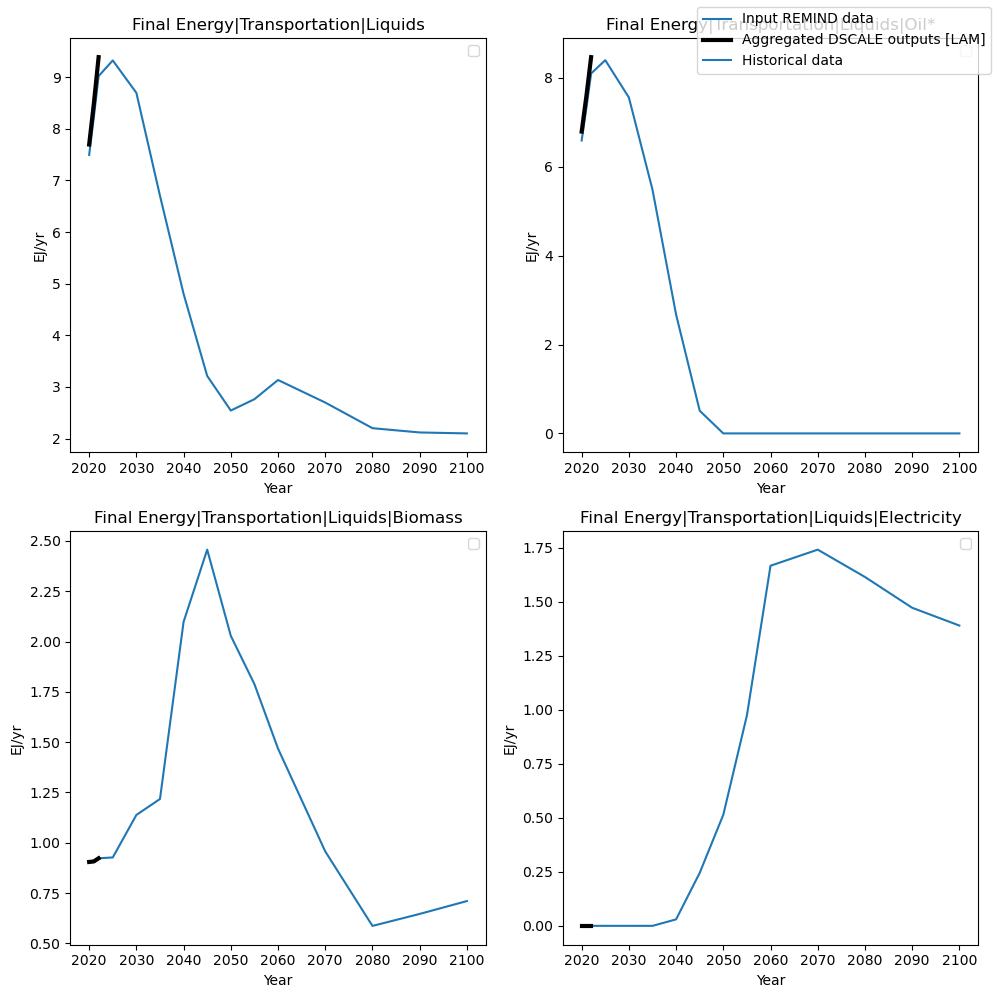

In [19]:
fuels = ['','|Oil*','|Biomass','|Electricity']
phase = 'Liquids'
sector = 'Transportation'


f, axes = plt.subplots(ncols=2,nrows=2,figsize=(10,10))

for count, ax in enumerate(axes.ravel()):

    # input_data.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2010,2101)).plot(ax=ax)
    input_data.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2020,2101)).plot(ax=ax)
    dscale_results_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2101)).plot(ax=ax)
    hist_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2101)).plot(ax=ax,color='k',lw=3)
    ax.set_title(f'Final Energy|{sector}|{phase}{fuels[count]}')

f.legend(['Input REMIND data','Aggregated DSCALE outputs [LAM]','Historical data'])
plt.tight_layout()

In [20]:
hist_agg

<class 'pyam.core.IamDataFrame'>
Index:
 * model    : IEA (1)
 * scenario : Historic data (1)
Timeseries data coordinates:
   region   : CAZ, CHA, EUR, IND, JPN, LAM, MEA, NEU, OAS, REF, ... World (13)
   variable : Final Energy, Final Energy|AFOFI, ... Secondary Energy|Heat|Wind (170)
   unit     : EJ/yr (1)
   year     : 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, ... 2022 (63)
Meta indicators:
   exclude (bool) False (1)

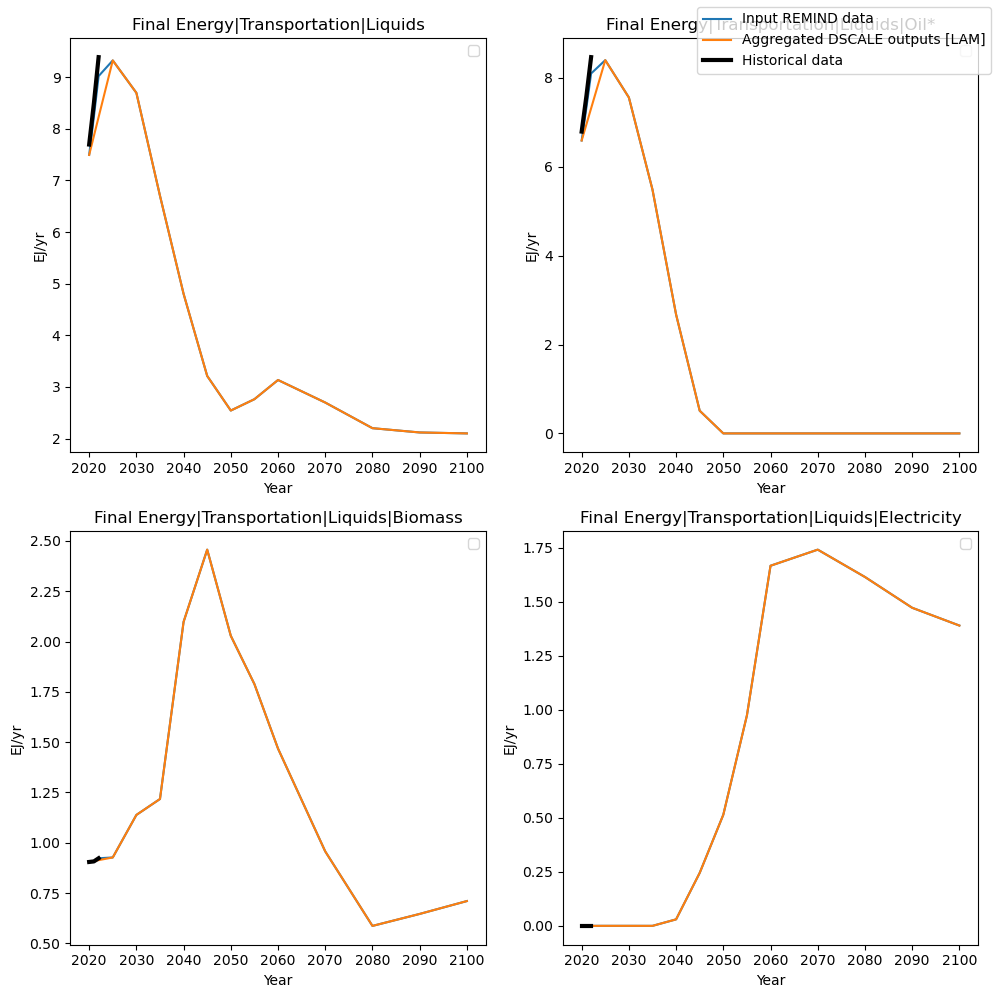

In [36]:
fuels = ['','|Oil*','|Biomass','|Electricity']
phase = 'Liquids'
sector = 'Transportation'


f, axes = plt.subplots(ncols=2,nrows=2,figsize=(10,10))

for count, ax in enumerate(axes.ravel()):

    # input_data.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2010,2101)).plot(ax=ax)
    input_data.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2020,2101)).plot(ax=ax)
    dscale_results_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2101)).plot(ax=ax)
    hist_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2101)).plot(ax=ax,color='k',lw=3)
    ax.set_title(f'Final Energy|{sector}|{phase}{fuels[count]}')

f.legend(['Input REMIND data','Aggregated DSCALE outputs [LAM]','Historical data'])
plt.tight_layout()

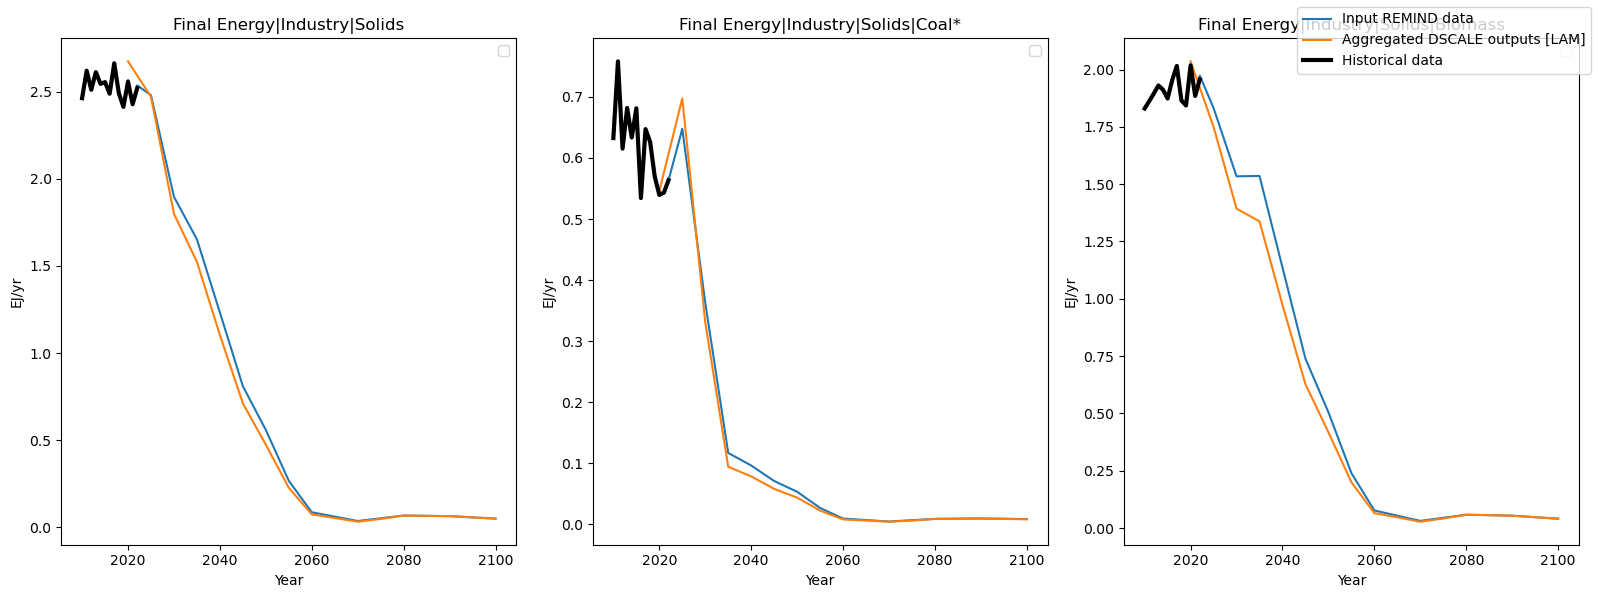

In [22]:
fuels = ['','|Coal*','|Biomass']
phase = 'Solids'
sector = 'Industry'


f, axes = plt.subplots(ncols=3,figsize=(16,6))

for count, ax in enumerate(axes.ravel()):

    input_data.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2010,2101)).plot(ax=ax)
    # input_data_processed.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2020,2101)).plot(ax=ax)
    dscale_results_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2101)).plot(ax=ax)
    hist_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2010,2101)).plot(ax=ax,color='k',lw=3)
    ax.set_title(f'Final Energy|{sector}|{phase}{fuels[count]}')

f.legend(['Input REMIND data','Aggregated DSCALE outputs [LAM]','Historical data'])
plt.tight_layout()

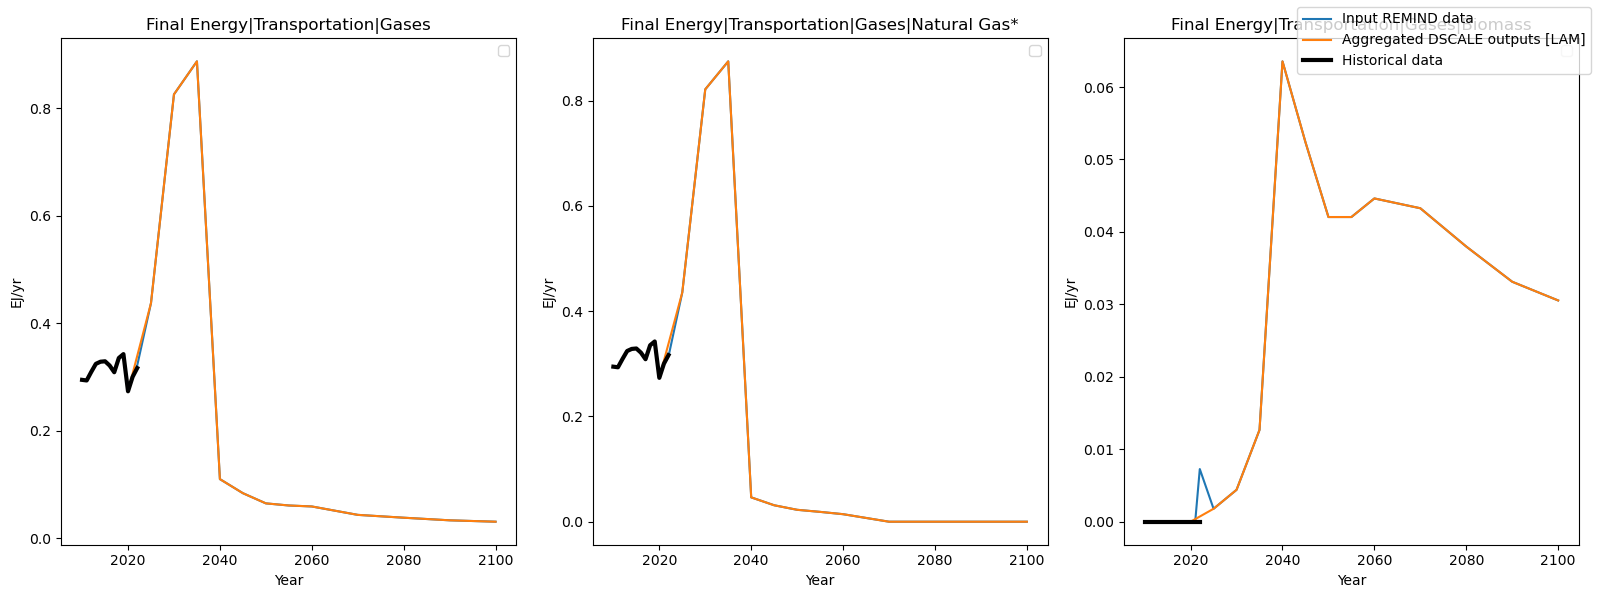

In [23]:
fuels = ['','|Natural Gas*','|Biomass']
phase = 'Gases'
sector = 'Transportation'


f, axes = plt.subplots(ncols=3,figsize=(16,6))

for count, ax in enumerate(axes.ravel()):

    input_data.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2010,2101)).plot(ax=ax)
    # input_data_processed.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='*LAM',scenario='NPE-core',year=range(2020,2101)).plot(ax=ax)
    dscale_results_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2020,2101)).plot(ax=ax)
    hist_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM',year=range(2010,2101)).plot(ax=ax,color='k',lw=3)
    ax.set_title(f'Final Energy|{sector}|{phase}{fuels[count]}')

f.legend(['Input REMIND data','Aggregated DSCALE outputs [LAM]','Historical data'])
plt.tight_layout()

## Second - start looking at country-level performance

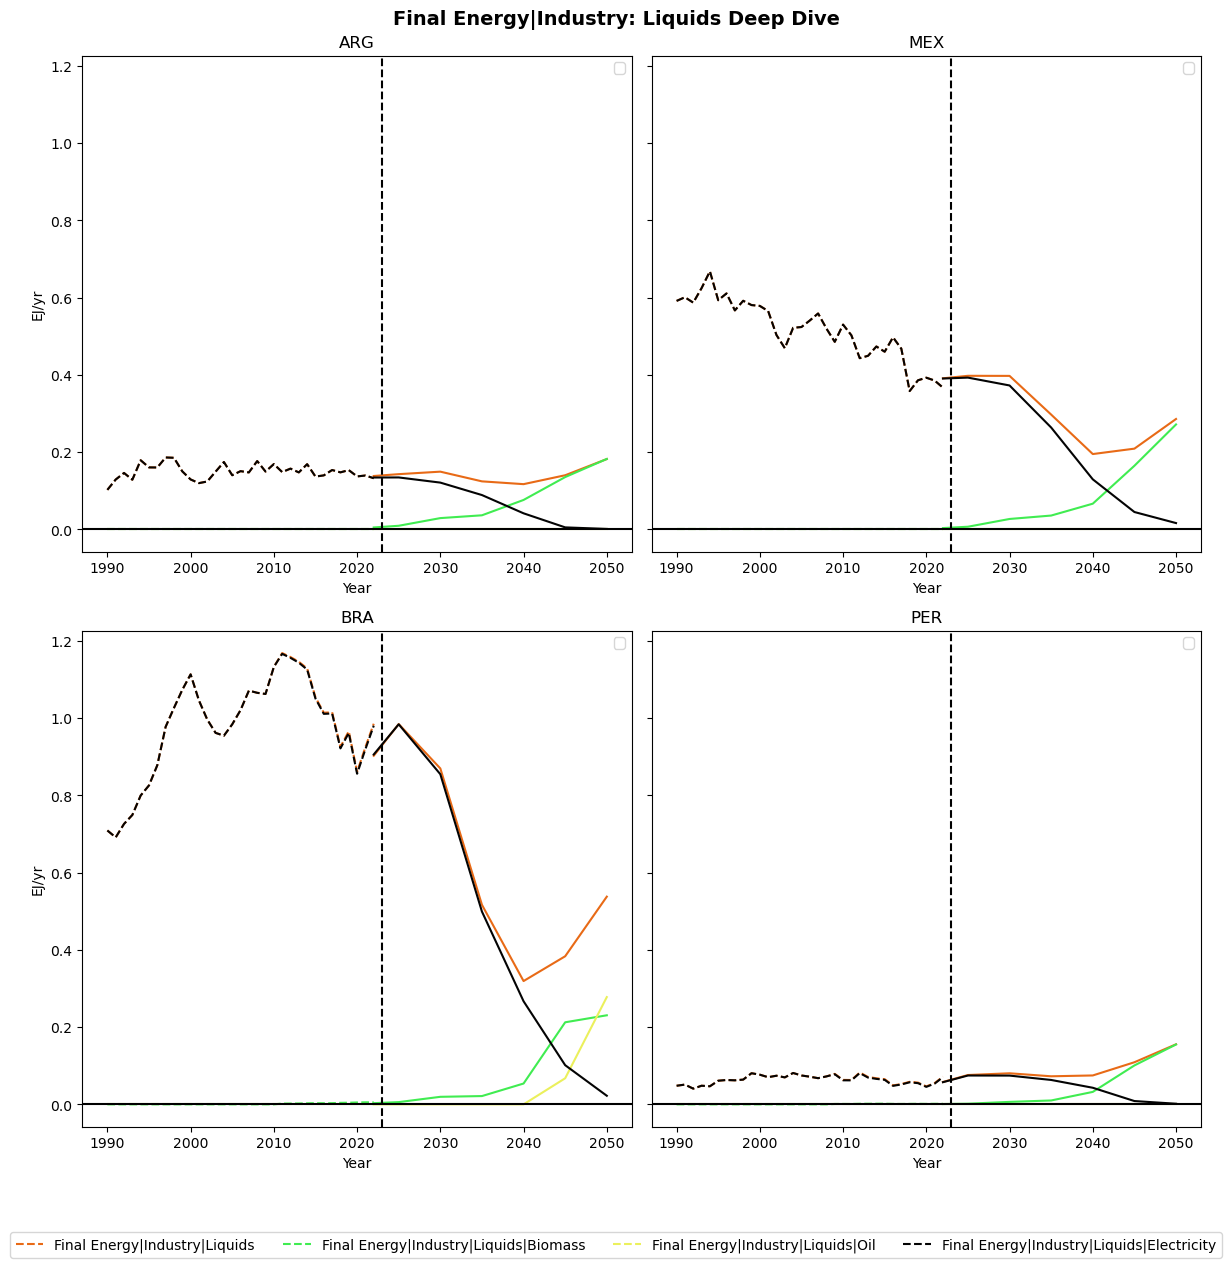

In [24]:
f, axes = plt.subplots(nrows=2,ncols=2,figsize=(12,12),sharey=True)

#plot_vars = final_energy("Residential and Commercial", ["Liquids", "Electricity", "Solids"])
plot_vars = final_energy("Industry", ["Liquids","Liquids|Biomass","Liquids|Oil","Liquids|Electricity"])#, "Electricity", "Gases", "Solids"])
plot_isos = ['ARG','MEX','BRA','PER']


color_map = {
   'Final Energy|Industry|Liquids': "#E86A16",
   'Final Energy|Industry|Liquids|Electricity': "#EBF05C",
   'Final Energy|Industry|Liquids|Biomass': "#40EC51",
   'Final Energy|Industry|Liquids|Oil':"#030303"
}

pyam.run_control().update({"color": {"variable": color_map}})

interpolated_data = dscale_results.filter(variable=plot_vars).interpolate(time=range(2010,2101,1))


for count, ax in enumerate(axes.ravel()[:len(plot_isos)]):
    hist_data.filter(variable=plot_vars, region=plot_isos[count], year=range(1990,2023)).plot(ax=ax, linestyle="--", color="variable")
    interpolated_data.filter(variable=plot_vars, region=plot_isos[count], year=range(2022,2051)).plot(ax=ax, color="variable")
    
    ax.axvline(x=2023,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(plot_isos[count])
    ax.legend([])


f.suptitle('Final Energy|Industry: Liquids Deep Dive',fontsize=14,fontweight='bold')
f.legend(plot_vars,ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()

## Third – looking at inter-sector and cross-sector consistency
Do carriers add up to the total per sector? Do sectors add up to the total final energy?

In [28]:
sector = 'Industry'

dscale_results.check_aggregate(
    f'Final Energy|{sector}',
    [
        f'Final Energy|{sector}|Liquids',
        f'Final Energy|{sector}|Solids',
        f'Final Energy|{sector}|Gases',
        f'Final Energy|{sector}|Heat',
        f'Final Energy|{sector}|Hydrogen',
        f'Final Energy|{sector}|Electricity',
    ], rtol=2.5e-2, atol=1e-2
).loc[isin(region='ZAF')]

pyam.core - INFO: `Final Energy|Industry` - 946 of 3667 rows are not aggregates of components


variable  \
model      scenario region variable              unit  year             
REMIND 3.4 NPE-core ZAF    Final Energy|Industry EJ/yr 2015    1.2050   
                                                       2020    1.1908   
                                                       2025    1.1817   
                                                       2030    1.4600   
                                                       2035    1.4811   
                                                       2040    1.6158   
                                                       2045    1.6304   
                                                       2050    1.5596   
                                                       2055    1.5409   
                                                       2060    1.5555   
                                                       2065    1.5607   

                                                             components  
model      scenario region variable              unit  year              
REMIND 3.4 NPE-core ZAF    Final Energy|Industry EJ/yr 2015    1.153017  
                                                       2020    1.133362  
                                                       2025    1.106943  
                                                       2030    1.369502  
                                                       2035    1.389015  
                                                       2040    1.490160  
                                                       2045    1.460980  
                                                       2050    1.420699  
                                                       2055    1.428086  
                                                       2060    1.469203  
                                                       2065    1.503481

In [27]:
sector = 'Residential and Commercial'

dscale_results.check_aggregate(
    f'Final Energy|{sector}',
    [
        f'Final Energy|{sector}|Liquids',
        f'Final Energy|{sector}|Solids',
        f'Final Energy|{sector}|Gases',
        f'Final Energy|{sector}|Heat',
        f'Final Energy|{sector}|Hydrogen',
        f'Final Energy|{sector}|Electricity',
    ], rtol=2.5e-2, atol=1e-2
).loc[isin(region='ZAF')]

pyam.core - INFO: `Final Energy|Residential and Commercial` - 726 of 3667 rows are not aggregates of components


variable  \
model      scenario region variable                                unit  year             
REMIND 3.4 NPE-core ZAF    Final Energy|Residential and Commercial EJ/yr 2030    0.5150   
                                                                         2035    0.5322   
                                                                         2040    0.5001   
                                                                         2045    0.4591   
                                                                         2050    0.5266   
                                                                         2055    0.5445   
                                                                         2060    0.5892   
                                                                         2065    0.5849   
                                                                         2070    0.5879   

                                                                               components  
model      scenario region variable                                unit  year              
REMIND 3.4 NPE-core ZAF    Final Energy|Residential and Commercial EJ/yr 2030    0.565618  
                                                                         2035    0.611542  
                                                                         2040    0.575067  
                                                                         2045    0.521600  
                                                                         2050    0.587238  
                                                                         2055    0.597352  
                                                                         2060    0.635692  
                                                                         2065    0.621156  
                                                                         2070    0.613367

In [54]:
dscale_results_agg.check_aggregate(
    f'Final Energy',
    [
        f'Final Energy|Residential and Commercial',
        f'Final Energy|Transportation',
        f'Final Energy|Industry'
    ], rtol=2.5e-2, atol=1e-2
).loc[isin(year=2025)]

[INFO] 14:52:27 - pyam.core: `Final Energy` - 236 of 247 rows are not aggregates of components


variable  \
model                 scenario region variable     unit  year             
REMIND-MAgPIE 3.3-4.8 NPE-core CAZ    Final Energy EJ/yr 2025   20.5533   
                               CHA    Final Energy EJ/yr 2025  166.8906   
                               EUR    Final Energy EJ/yr 2025   73.2000   
                               IND    Final Energy EJ/yr 2025   51.1043   
                               JPN    Final Energy EJ/yr 2025   16.9734   
                               LAM    Final Energy EJ/yr 2025   46.6553   
                               MEA    Final Energy EJ/yr 2025   59.8373   
                               NEU    Final Energy EJ/yr 2025   12.4043   
                               OAS    Final Energy EJ/yr 2025   59.1191   
                               REF    Final Energy EJ/yr 2025   50.4591   
                               SSA    Final Energy EJ/yr 2025   22.7741   
                               USA    Final Energy EJ/yr 2025  119.8717   
                               World  Final Energy EJ/yr 2025  699.8425   

                                                               components  
model                 scenario region variable     unit  year              
REMIND-MAgPIE 3.3-4.8 NPE-core CAZ    Final Energy EJ/yr 2025     12.0846  
                               CHA    Final Energy EJ/yr 2025    103.8225  
                               EUR    Final Energy EJ/yr 2025     44.6647  
                               IND    Final Energy EJ/yr 2025     31.9623  
                               JPN    Final Energy EJ/yr 2025     10.2584  
                               LAM    Final Energy EJ/yr 2025     28.7456  
                               MEA    Final Energy EJ/yr 2025     33.5140  
                               NEU    Final Energy EJ/yr 2025      7.5104  
                               OAS    Final Energy EJ/yr 2025     36.4837  
                               REF    Final Energy EJ/yr 2025     30.2091  
                               SSA    Final Energy EJ/yr 2025     17.2483  
                               USA    Final Energy EJ/yr 2025     70.8007  
                               World  Final Energy EJ/yr 2025    427.3043

In [47]:
sector = 'Residential and Commercial'

dscale_results.check_aggregate(
    f'Final Energy',
    [
        f'Final Energy|Residential and Commercial',
        f'Final Energy|Transportation',
        f'Final Energy|Industry'
    ], rtol=2.5e-2, atol=1e-2
).loc[isin(region='BRA')]

[INFO] 14:49:41 - pyam.core: `Final Energy` - 2579 of 3667 rows are not aggregates of components


variable  \
model                 scenario region variable     unit  year             
REMIND-MAgPIE 3.3-4.8 NPE-core BRA    Final Energy EJ/yr 2010   13.6674   
                                                         2015   14.7397   
                                                         2020   13.9674   
                                                         2025   16.9847   
                                                         2030   15.3797   
                                                         2035   13.8620   
                                                         2040   13.3756   
                                                         2045   14.1198   
                                                         2050   14.8404   
                                                         2055   15.1650   
                                                         2060   15.9225   
                                                         2065   15.4815   
                                                         2070   15.0351   
                                                         2075   14.6366   
                                                         2080   14.2949   
                                                         2085   14.2356   
                                                         2090   14.2015   
                                                         2095   13.9452   
                                                         2100   13.7287   

                                                               components  
model                 scenario region variable     unit  year              
REMIND-MAgPIE 3.3-4.8 NPE-core BRA    Final Energy EJ/yr 2010      8.4470  
                                                         2015      9.0772  
                                                         2020      8.8059  
                                                         2025     11.1385  
                                                         2030     10.7181  
                                                         2035     10.0570  
                                                         2040      9.7649  
                                                         2045     10.1810  
                                                         2050     10.6270  
                                                         2055     11.1192  
                                                         2060     11.9544  
                                                         2065     11.9402  
                                                         2070     11.9009  
                                                         2075     11.8462  
                                                         2080     11.8147  
                                                         2085     11.7526  
                                                         2090     11.7110  
                                                         2095     11.4980  
                                                         2100     11.3175

In [29]:
sector = 'Transportation'

dscale_results.check_aggregate(
    f'Final Energy|{sector}',
    [
        f'Final Energy|{sector}|Liquids',
        f'Final Energy|{sector}|Solids',
        f'Final Energy|{sector}|Gases',
        f'Final Energy|{sector}|Heat',
        f'Final Energy|{sector}|Hydrogen',
        f'Final Energy|{sector}|Electricity',
    ], rtol = 1e-2
).loc[isin(region='BRA')]

pyam.core - INFO: `Final Energy|Transportation` - 2230 of 3667 rows are not aggregates of components


variable  \
model      scenario region variable                    unit  year             
REMIND 3.4 NPE-core BRA    Final Energy|Transportation EJ/yr 2010    2.9439   
                                                             2015    3.5702   
                                                             2020    3.3811   
                                                             2025    4.7345   
                                                             2030    4.7383   
                                                             2035    4.0803   
                                                             2040    3.3039   
                                                             2045    3.0520   
                                                             2050    3.1572   
                                                             2055    3.4362   
                                                             2060    3.7570   
                                                             2065    3.7226   
                                                             2070    3.6804   
                                                             2075    3.6433   

                                                                   components  
model      scenario region variable                    unit  year              
REMIND 3.4 NPE-core BRA    Final Energy|Transportation EJ/yr 2010    2.887248  
                                                             2015    3.496493  
                                                             2020    3.249149  
                                                             2025    3.832439  
                                                             2030    4.467588  
                                                             2035    4.575893  
                                                             2040    4.296628  
                                                             2045    4.268700  
                                                             2050    4.318785  
                                                             2055    4.382310  
                                                             2060    4.483532  
                                                             2065    4.228906  
                                                             2070    3.999014  
                                                             2075    3.793804

In [30]:
dscale_results_agg.filter(variable='Final Energy|R**',year=2020,region='LAM')._data.sort_values()

model       scenario  region  variable                                                     unit   year
REMIND 3.4  NPE-core  LAM     Final Energy|Residential and Commercial|Gases|Electricity    EJ/yr  2020    0.000000
                              Final Energy|Residential and Commercial|Hydrogen             EJ/yr  2020    0.000000
                              Final Energy|Residential and Commercial|Liquids|Electricity  EJ/yr  2020    0.000000
                              Final Energy|Residential and Commercial|Gases|Biomass        EJ/yr  2020    0.000569
                              Final Energy|Residential and Commercial|Solids|Coal          EJ/yr  2020    0.002500
                              Final Energy|Residential and Commercial|Liquids|Biomass      EJ/yr  2020    0.009429
                              Final Energy|Residential and Commercial|Heat                 EJ/yr  2020    0.090000
                              Final Energy|Residential and Commercial|Gases|Natural Gas    E

In [31]:
dscale_results.filter(variable='Final Energy|Re**',region='BRA',year=2020)._data

model       scenario  region  variable                                                     unit   year
REMIND 3.4  NPE-core  BRA     Final Energy|Residential and Commercial                      EJ/yr  2020    1.682700
                              Final Energy|Residential and Commercial|Electricity          EJ/yr  2020    0.995300
                              Final Energy|Residential and Commercial|Gases                EJ/yr  2020    0.020086
                              Final Energy|Residential and Commercial|Gases|Biomass        EJ/yr  2020    0.000006
                              Final Energy|Residential and Commercial|Gases|Electricity    EJ/yr  2020    0.000000
                              Final Energy|Residential and Commercial|Gases|Natural Gas    EJ/yr  2020    0.021563
                              Final Energy|Residential and Commercial|Heat                 EJ/yr  2020    0.035300
                              Final Energy|Residential and Commercial|Hydrogen             E

In [95]:
dscale_results_agg.filter(variable='Final Energy|Re**',region='LAM',year=2020)._data

model                  scenario  region  variable                                                     unit   year
REMIND-MAgPIE 3.3-4.8  NPE-core  LAM     Final Energy|Residential and Commercial                      EJ/yr  2020    3.238400
                                         Final Energy|Residential and Commercial|Electricity          EJ/yr  2020    2.443500
                                         Final Energy|Residential and Commercial|Gases                EJ/yr  2020    0.599119
                                         Final Energy|Residential and Commercial|Gases|Biomass        EJ/yr  2020    0.000569
                                         Final Energy|Residential and Commercial|Gases|Electricity    EJ/yr  2020    0.000000
                                         Final Energy|Residential and Commercial|Gases|Natural Gas    EJ/yr  2020    0.598550
                                         Final Energy|Residential and Commercial|Heat                 EJ/yr  2020    0.089400
    

In [93]:
(8.000800+6.505900+3.238400)

17.745099999999997

<Axes: title={'center': 'model: REMIND 3.4 - scenario: NPE-core - region: LAM - variable: Final Energy'}, xlabel='Year', ylabel='EJ/yr'>

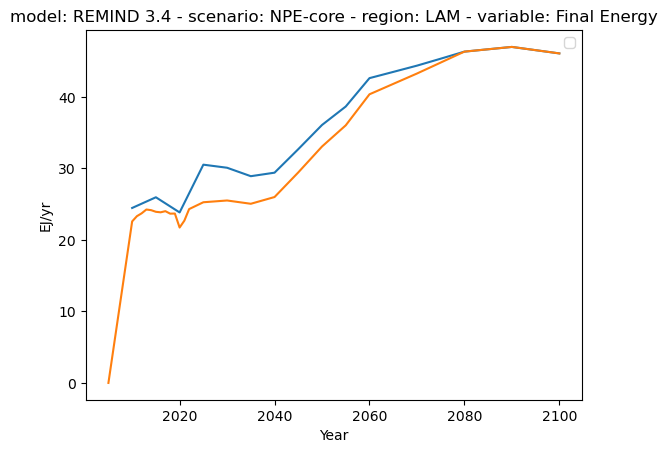

In [32]:
dscale_results_agg.filter(variable=
    [
        'Final Energy',
        # 'Final Energy|Residential and Commercial',
        # 'Final Energy|Transportation',
        # 'Final Energy|Industry'
    ],
        region='LAM').plot()

input_data.filter(variable=
    [
        'Final Energy',
        # 'Final Energy|Residential and Commercial',
        # 'Final Energy|Transportation',
        # 'Final Energy|Industry'
    ],
        region='LAM').plot(ax=plt.gca())

In [33]:
dscale_results.filter(variable='*Liquids*El*').variable

['Final Energy|Industry|Liquids|Electricity',
 'Final Energy|Residential and Commercial|Liquids|Electricity',
 'Final Energy|Transportation|Liquids|Electricity']

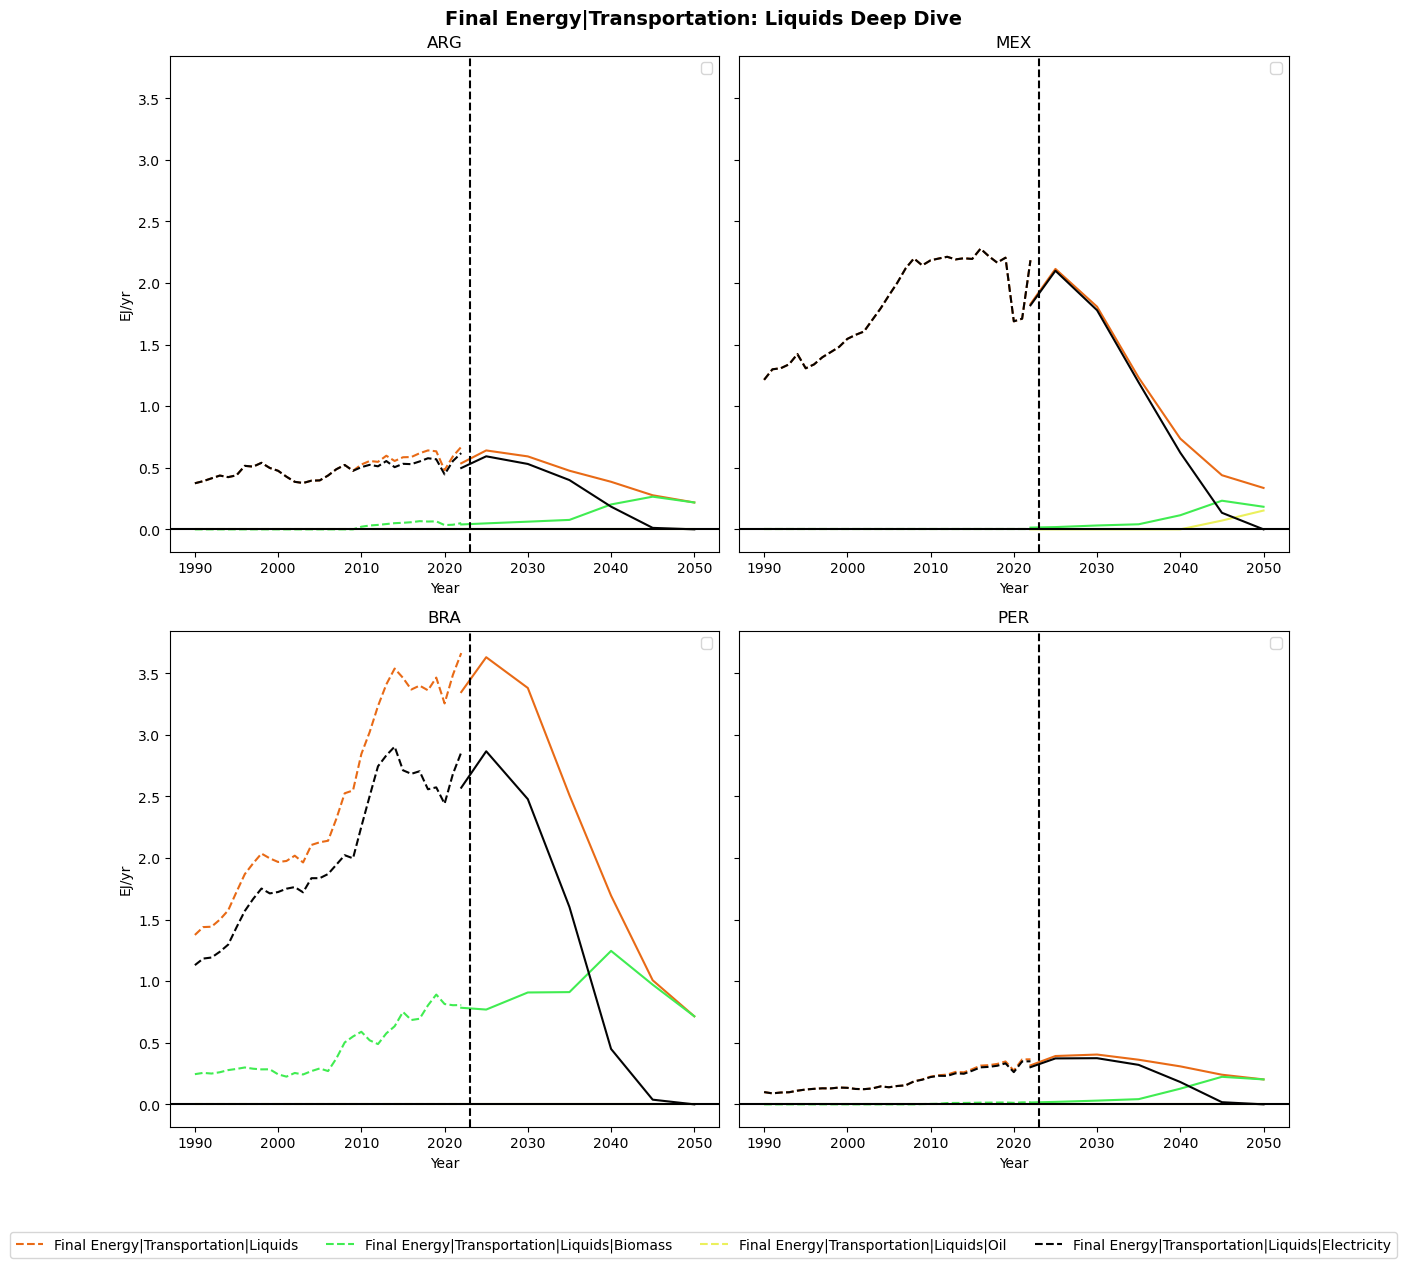

In [34]:
f, axes = plt.subplots(nrows=2,ncols=2,figsize=(12,12),sharey=True)

#plot_vars = final_energy("Residential and Commercial", ["Liquids", "Electricity", "Solids"])
plot_vars = final_energy("Transportation", ["Liquids","Liquids|Biomass","Liquids|Oil","Liquids|Electricity"])#, "Electricity", "Gases", "Solids"])
plot_isos = ['ARG','MEX','BRA','PER']


color_map = {
   'Final Energy|Transportation|Liquids': "#E86A16",
   'Final Energy|Transportation|Liquids|Electricity': "#EBF05C",
   'Final Energy|Transportation|Liquids|Biomass': "#40EC51",
   'Final Energy|Transportation|Liquids|Oil':"#030303"
}

pyam.run_control().update({"color": {"variable": color_map}})

interpolated_data = dscale_results.filter(variable=plot_vars).interpolate(time=range(2010,2101,1))


for count, ax in enumerate(axes.ravel()[:len(plot_isos)]):
    hist_data.filter(variable=plot_vars, region=plot_isos[count], year=range(1990,2023)).plot(ax=ax, linestyle="--", color="variable")
    interpolated_data.filter(variable=plot_vars, region=plot_isos[count], year=range(2022,2051)).plot(ax=ax, color="variable")
    
    ax.axvline(x=2023,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(plot_isos[count])
    ax.legend([])


f.suptitle('Final Energy|Transportation: Liquids Deep Dive',fontsize=14,fontweight='bold')
f.legend(plot_vars,ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()

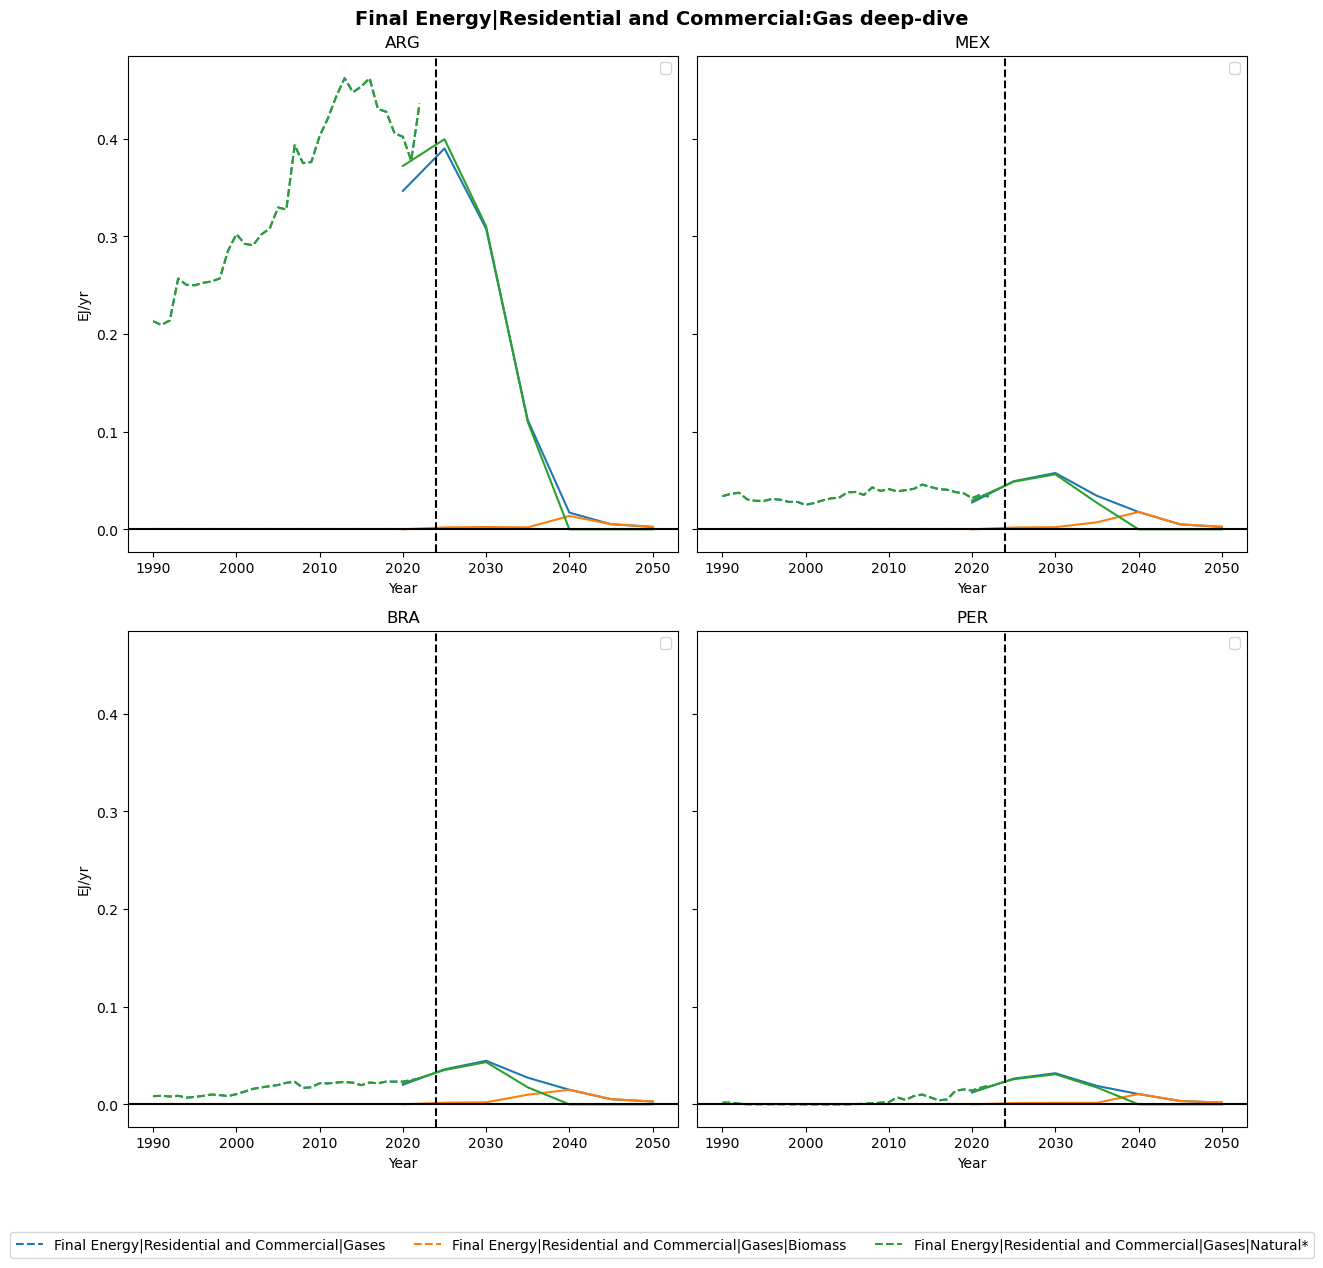

In [35]:
f, axes = plt.subplots(nrows=2,ncols=2,figsize=(12,12),sharey=True)

#plot_vars = final_energy("Residential and Commercial", ["Liquids", "Electricity", "Solids"])
plot_vars = final_energy("Residential and Commercial", ["Gases","Gases|Biomass","Gases|Natural*"])#, "Electricity", "Gases", "Solids"])
plot_isos = ['ARG','MEX','BRA','PER']

interpolated_data = dscale_results.filter(variable=plot_vars).interpolate(time=range(2010,2101,1))


for count, ax in enumerate(axes.ravel()[:len(plot_isos)]):
    hist_data.filter(variable=plot_vars, region=plot_isos[count], year=range(1990,2023)).plot(ax=ax, linestyle="--", color="variable")
    interpolated_data.filter(variable=plot_vars, region=plot_isos[count], year=range(2020,2051)).plot(ax=ax, color="variable")
    
    ax.axvline(x=2024,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(plot_isos[count])
    ax.legend([])


f.suptitle('Final Energy|Residential and Commercial:Gas deep-dive',fontsize=14,fontweight='bold')
f.legend(plot_vars,ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()

In [27]:
dscale_results.filter(region='ARG',variable='Final Energy').timeseries()

,,,,,2010,2015,2020,2025,2030,2035,2040,2045,2050,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
model,scenario,region,variable,unit,,,,,,,,,,,,,,,,,,,
REMIND-MAgPIE 3.3-4.8,NPE-core,ARG,Final Energy,EJ/yr,4.0079,4.2792,3.7187,4.5623,4.1894,3.6915,3.4671,3.5641,3.6693,3.6956,3.8428,3.7135,3.5987,3.5022,3.4101,3.4011,3.3929,3.3325,3.2748


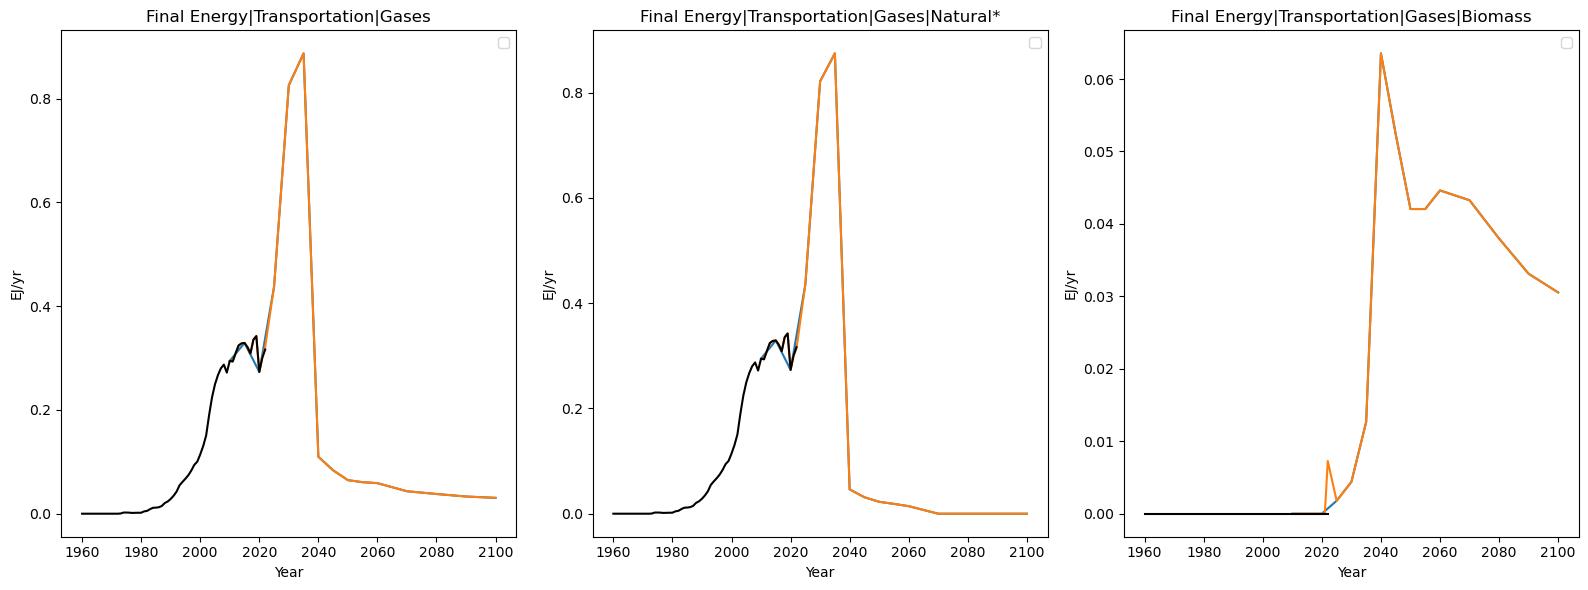

In [38]:
fuels = ['','|Natural*','|Biomass']
phase = 'Gases'
sector = 'Transportation'


f, axes = plt.subplots(ncols=3,figsize=(16,6))

for count, ax in enumerate(axes.ravel()):

    dscale_results_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM').plot(ax=ax)
    input_data.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM').plot(ax=ax)
    hist_agg.filter(variable=f'Final Energy|{sector}|{phase}{fuels[count]}',region='LAM').plot(ax=ax,color='k')
    ax.set_title(f'Final Energy|{sector}|{phase}{fuels[count]}')

plt.tight_layout()

## Energy mix

In [16]:
transport_mix_variable = [
 'Final Energy|Transportation|Electricity',
 'Final Energy|Transportation|Gases|Biomass',
 'Final Energy|Transportation|Gases|Electricity',
 'Final Energy|Transportation|Gases|Natural Gas',
 'Final Energy|Transportation|Hydrogen',
 'Final Energy|Transportation|Liquids|Biomass',
 'Final Energy|Transportation|Liquids|Coal',
 'Final Energy|Transportation|Liquids|Electricity',
 'Final Energy|Transportation|Liquids|Oil'
 ]

In [17]:
color_map = {
    'Final Energy|Transportation|Electricity': "#4ed670",
    'Final Energy|Transportation|Gases|Biomass': '#4d4d4d',
    'Final Energy|Transportation|Gases|Electricity': "#908E8E",
    'Final Energy|Transportation|Gases|Natural Gas': '#8da0cb',
    'Final Energy|Transportation|Hydrogen': "#5fa2cf",
    'Final Energy|Transportation|Liquids|Biomass': '#e78ac3',
    'Final Energy|Transportation|Liquids|Coal': "#9F9F9F",
    'Final Energy|Transportation|Liquids|Electricity': '#ffd92f',
    'Final Energy|Transportation|Liquids|Oil': '#1f78b4',
    # 'Secondary Energy|Electricity|Non-Biomass Renewables': '#ffd92f',
    # 'Secondary Energy|Electricity|Hydrogen': "#d30985", 
}

hatch = {
    'v0.0__REMIND-MAgPIE 2.1-4.3__DeepElec_SSP2_ HighRE_Budg900' : '//'
}

linestyle = {
    'Secondary Energy|Electricity|Gas' : '--'
}

pyam.run_control().update({"color": {"variable": color_map}, "hatch" : {"scenario" : hatch}})

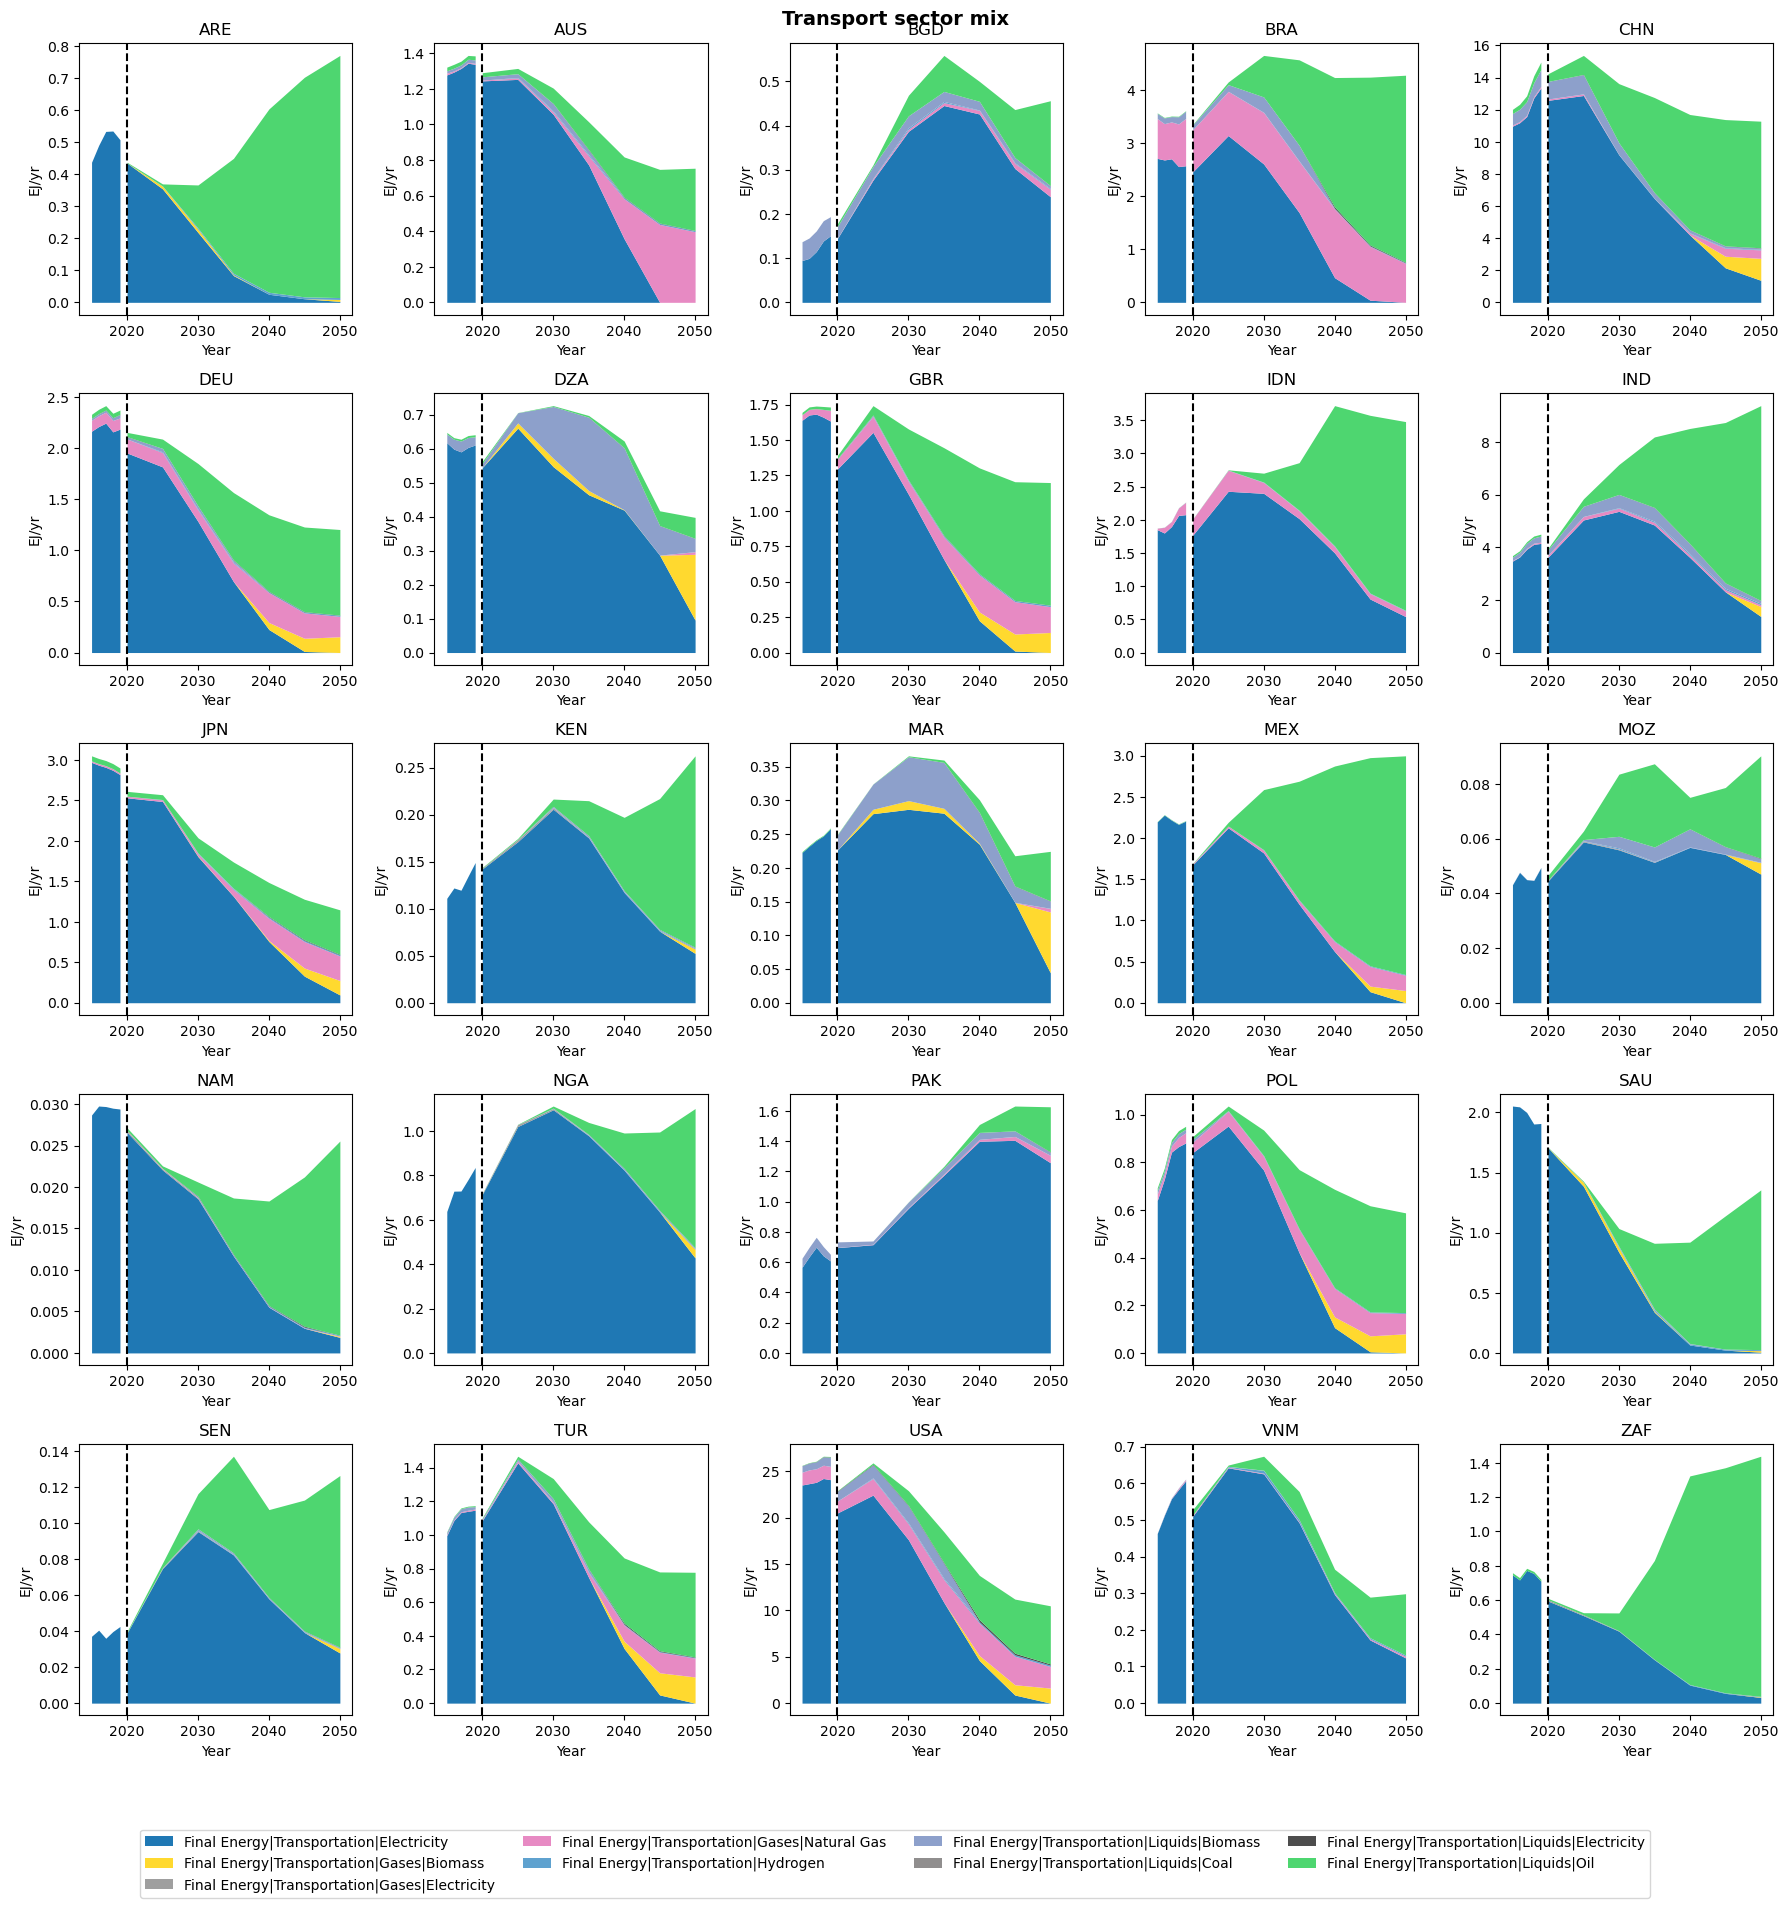

In [19]:
year_proj = [2020,
 2025,
 2030,
 2035,
 2040,
 2045,
 2050,
#  2055,
#  2060,
#  2065,
#  2070,
#  2075,
#  2080,
#  2085,
#  2090,
#  2095,
#  2100
 ]

f, axes = plt.subplots(nrows=5, ncols=5, figsize=(18, 18))

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    dscale_results.filter(
        scenario='NPE-core',
        region=IKEA_ISOS[count],
        variable=transport_mix_variable,
        year = year_proj
    ).plot.stack(ax=ax,)

    hist_data_iea.filter(
        region=IKEA_ISOS[count],
        variable=transport_mix_variable,
        year=[2015, 2016, 2017, 2018, 2019]
    ).plot.stack(ax=ax)

    ax.axvline(x=2020, color='k', ls='--')
    ax.set_title(IKEA_ISOS[count])
    ax.legend().remove()

# ax.legend(ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

f.suptitle('Transport sector mix',fontsize=14,fontweight='bold')
f.legend(transport_mix_variable,ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()

In [15]:
industry_mix_variable = [
 'Final Energy|Industry|Electricity',
 'Final Energy|Industry|Gases|Biomass',
 'Final Energy|Industry|Gases|Electricity',
 'Final Energy|Industry|Gases|Natural Gas',
 'Final Energy|Industry|Hydrogen',
 'Final Energy|Industry|Liquids|Biomass',
 'Final Energy|Industry|Liquids|Coal',
 'Final Energy|Industry|Liquids|Electricity',
 'Final Energy|Industry|Liquids|Oil',
 'Final Energy|Industry|Solids|Biomass',
 'Final Energy|Industry|Solids|Coal'
 ]

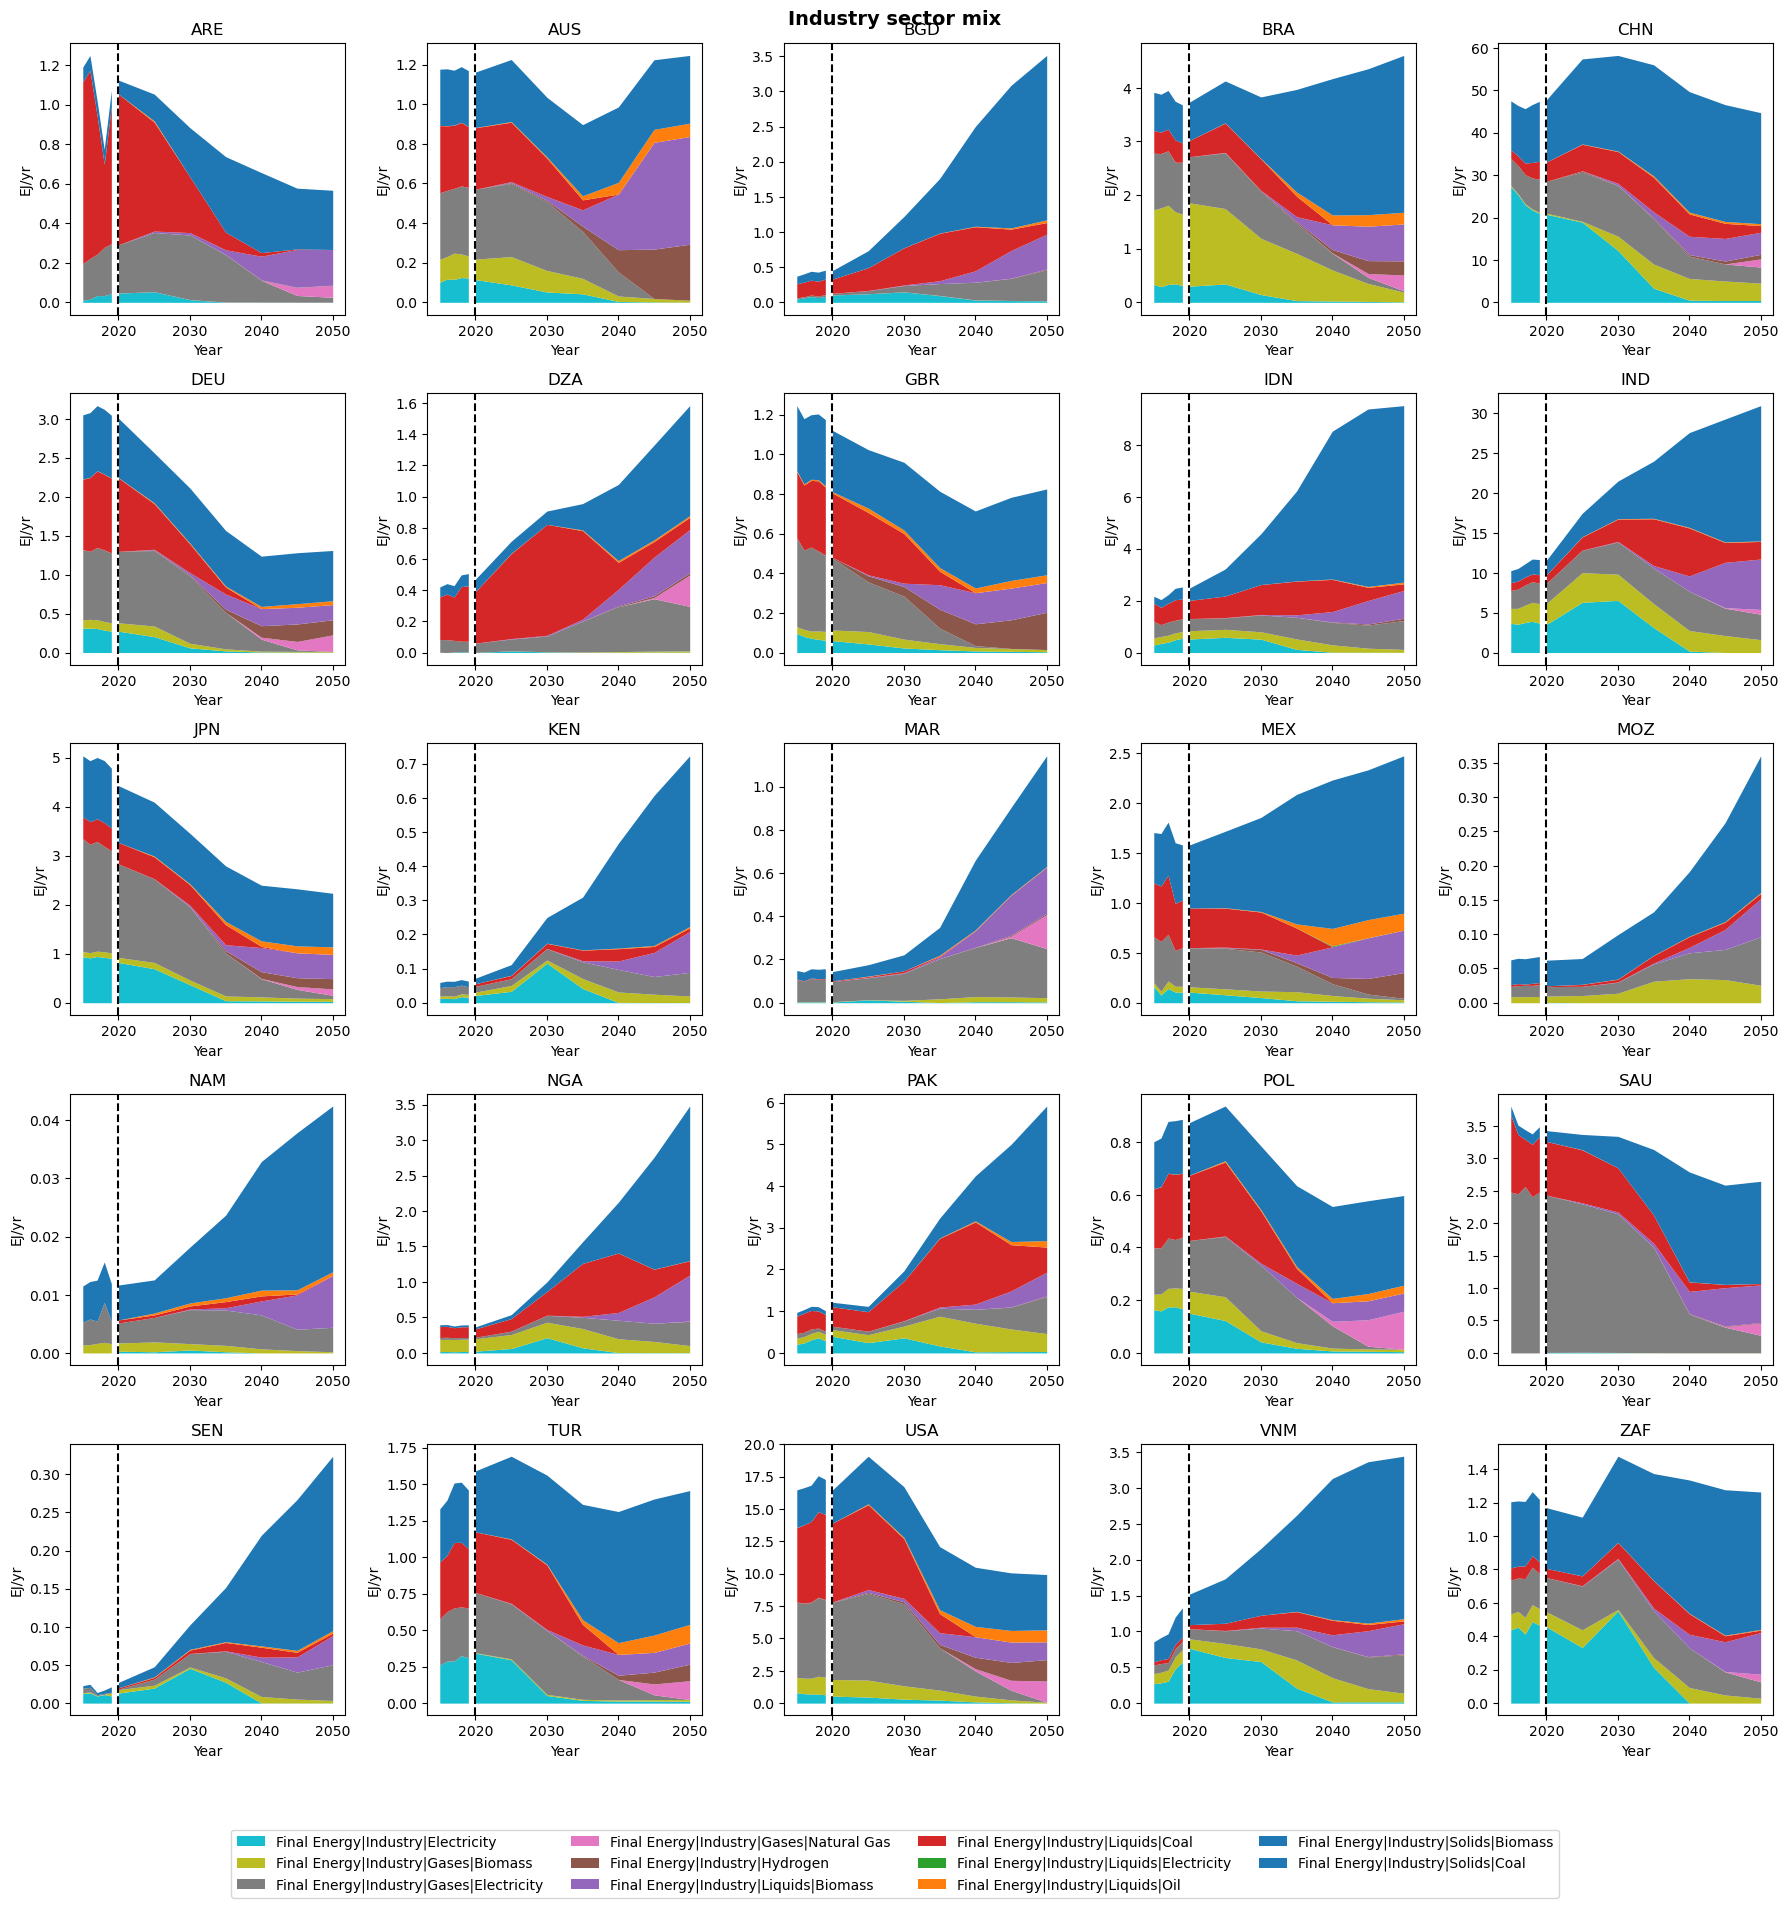

In [16]:
year_proj = [2020,
 2025,
 2030,
 2035,
 2040,
 2045,
 2050,
#  2055,
#  2060,
#  2065,
#  2070,
#  2075,
#  2080,
#  2085,
#  2090,
#  2095,
#  2100
 ]

f, axes = plt.subplots(nrows=5, ncols=5, figsize=(18, 18))

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    dscale_results.filter(
        scenario='NPE-core',
        region=IKEA_ISOS[count],
        variable=industry_mix_variable,
        year = year_proj
    ).plot.stack(ax=ax,)

    hist_data_iea.filter(
        region=IKEA_ISOS[count],
        variable=industry_mix_variable,
        year=[2015, 2016, 2017, 2018, 2019]
    ).plot.stack(ax=ax)

    ax.axvline(x=2020, color='k', ls='--')
    ax.set_title(IKEA_ISOS[count])
    ax.legend().remove()

# ax.legend(ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

f.suptitle('Industry sector mix',fontsize=14,fontweight='bold')
f.legend(industry_mix_variable,ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()

In [17]:
buildings_mix_variable = [
 'Final Energy|Residential and Commercial|Electricity',
 'Final Energy|Residential and Commercial|Gases|Biomass',
 'Final Energy|Residential and Commercial|Gases|Electricity',
 'Final Energy|Residential and Commercial|Gases|Natural Gas',
 'Final Energy|Residential and Commercial|Hydrogen',
 'Final Energy|Residential and Commercial|Liquids|Biomass',
 'Final Energy|Residential and Commercial|Liquids|Coal',
 'Final Energy|Residential and Commercial|Liquids|Electricity',
 'Final Energy|Residential and Commercial|Liquids|Oil',
 'Final Energy|Residential and CommercialSolids|Biomass',
 'Final Energy|Residential and Commercial|Solids|Coal'
 ]

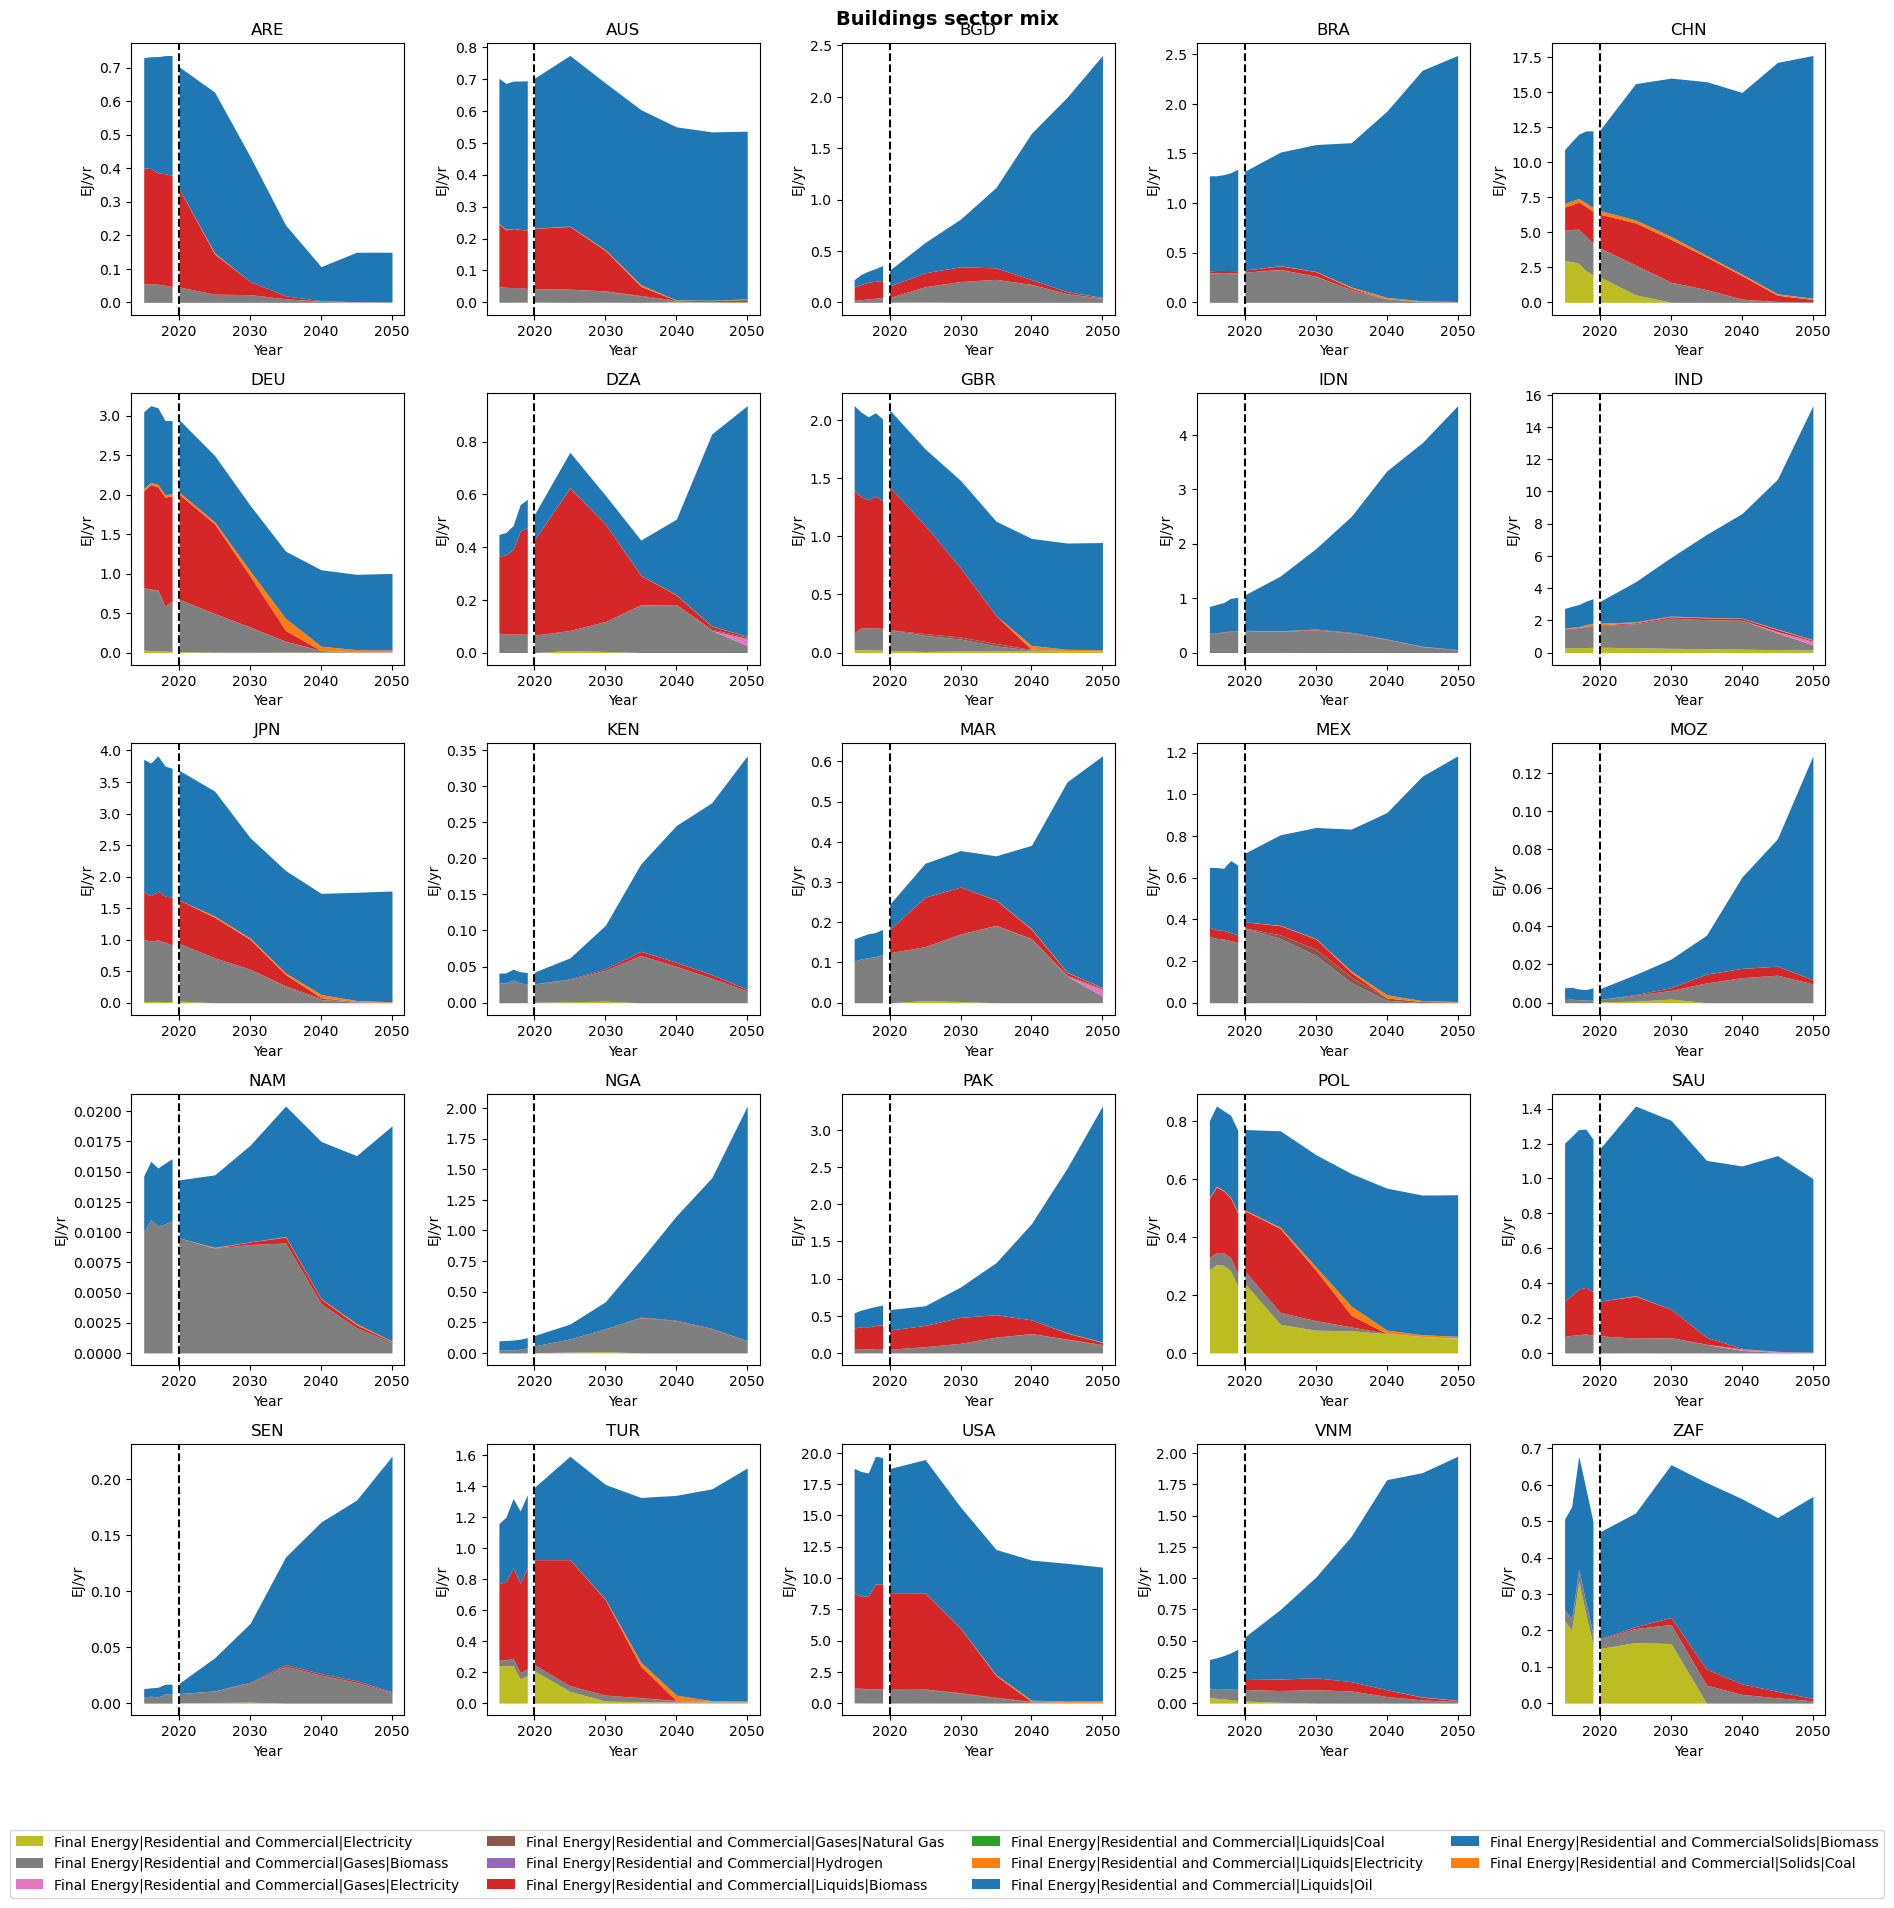

In [18]:
year_proj = [2020,
 2025,
 2030,
 2035,
 2040,
 2045,
 2050,
#  2055,
#  2060,
#  2065,
#  2070,
#  2075,
#  2080,
#  2085,
#  2090,
#  2095,
#  2100
 ]

f, axes = plt.subplots(nrows=5, ncols=5, figsize=(18, 18))

# colors = [color_map[v] for v in power_mix_var]

for count, ax in enumerate(axes.ravel()):

    dscale_results.filter(
        scenario='NPE-core',
        region=IKEA_ISOS[count],
        variable=buildings_mix_variable,
        year = year_proj
    ).plot.stack(ax=ax,)

    hist_data_iea.filter(
        region=IKEA_ISOS[count],
        variable=buildings_mix_variable,
        year=[2015, 2016, 2017, 2018, 2019]
    ).plot.stack(ax=ax)

    ax.axvline(x=2020, color='k', ls='--')
    ax.set_title(IKEA_ISOS[count])
    ax.legend().remove()

# ax.legend(ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])

f.suptitle('Buildings sector mix',fontsize=14,fontweight='bold')
f.legend(buildings_mix_variable,ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()